In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
import pickle as pkl

import importlib
import ibl_info.rnn_utility_functions as rnn_utility
from glob import glob
import re

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import recall_score, precision_score, accuracy_score

2025-01-30 16:11:50.004 | INFO     | ibl_info.config:<module>:8 - PROJ_ROOT path is: /Users/dkundu/Documents/phd/ibl-partial-info-decomp


In [44]:
importlib.reload(rnn_utility)

<module 'ibl_info.rnn_utility_functions' from '/Users/dkundu/Documents/phd/ibl-partial-info-decomp/ibl_info/rnn_utility_functions.py'>

In [3]:
## load one session, and organize everything in one function


def load_session(path):
    with open(path, "rb") as f:
        rnn_model = pkl.load(f)
    return rnn_model["session_data"]

In [4]:
proportions, correct, iterations = rnn_utility.collate_frozen_behavior(
    "../../ann-rnn-modified/data/fixed_time_stim_fixed_weights/"
)

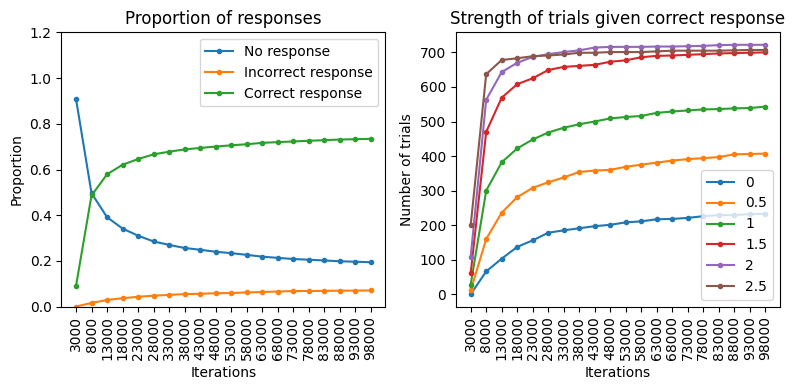

In [6]:
starting_point = 3000
rnn_utility.plot_frozen_behavior(proportions, correct, iterations + starting_point, False)

In [43]:
proportions, correct, iterations = rnn_utility.collate_frozen_behavior(
    "../../ann-rnn-modified/data/adamalltheway/"
)

In [37]:
# x = np.arange(0, 99000, 4000)
# locs = np.argwhere(np.isin(iterations, x)).reshape(
#     -1,
# )

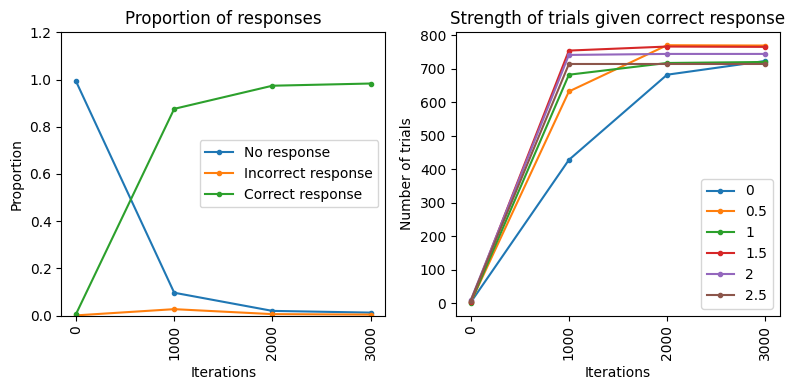

In [44]:
rnn_utility.plot_frozen_behavior(proportions, correct, iterations, False)

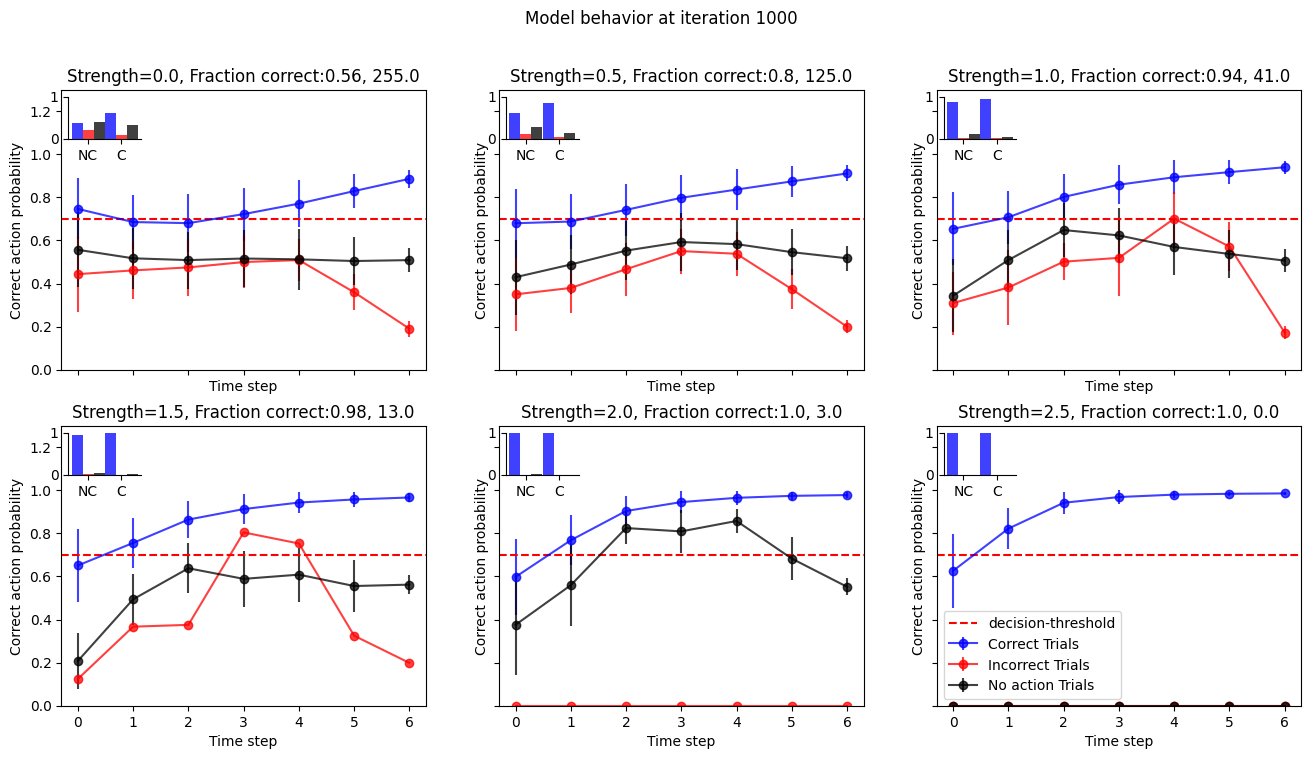

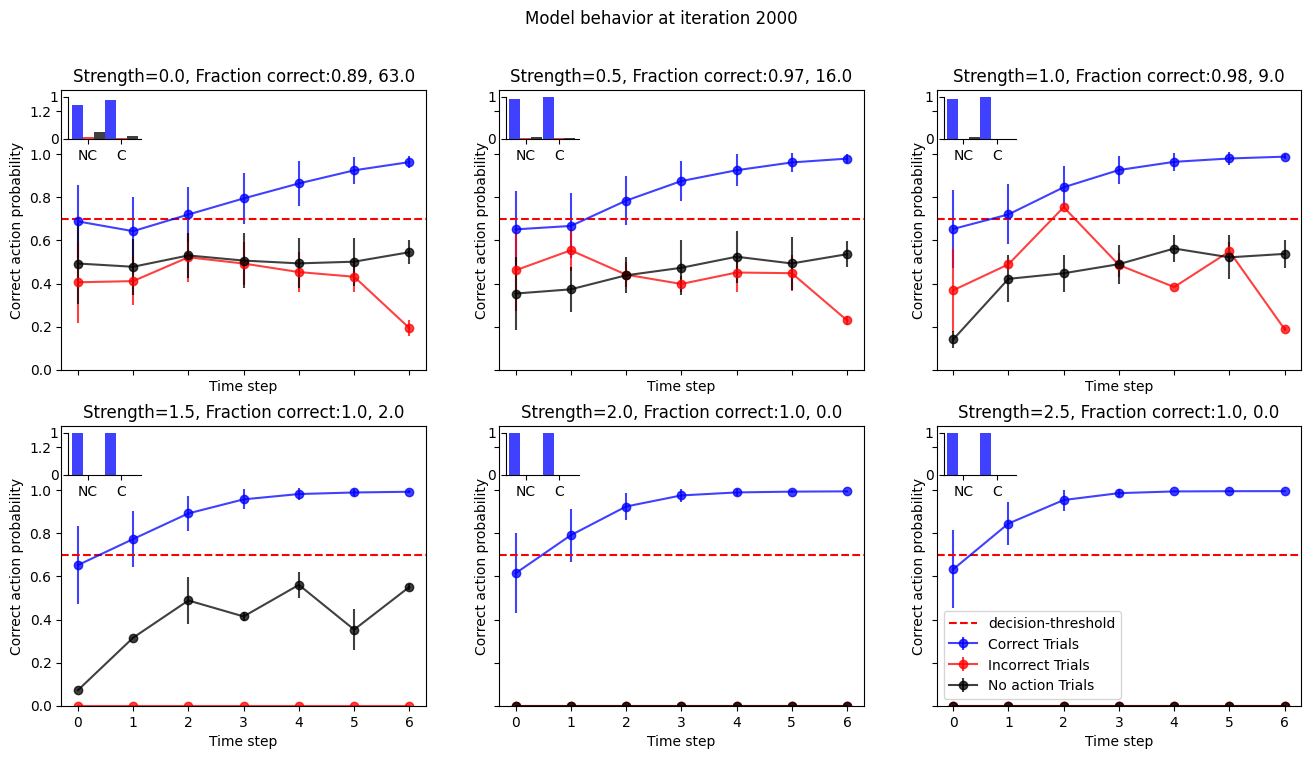

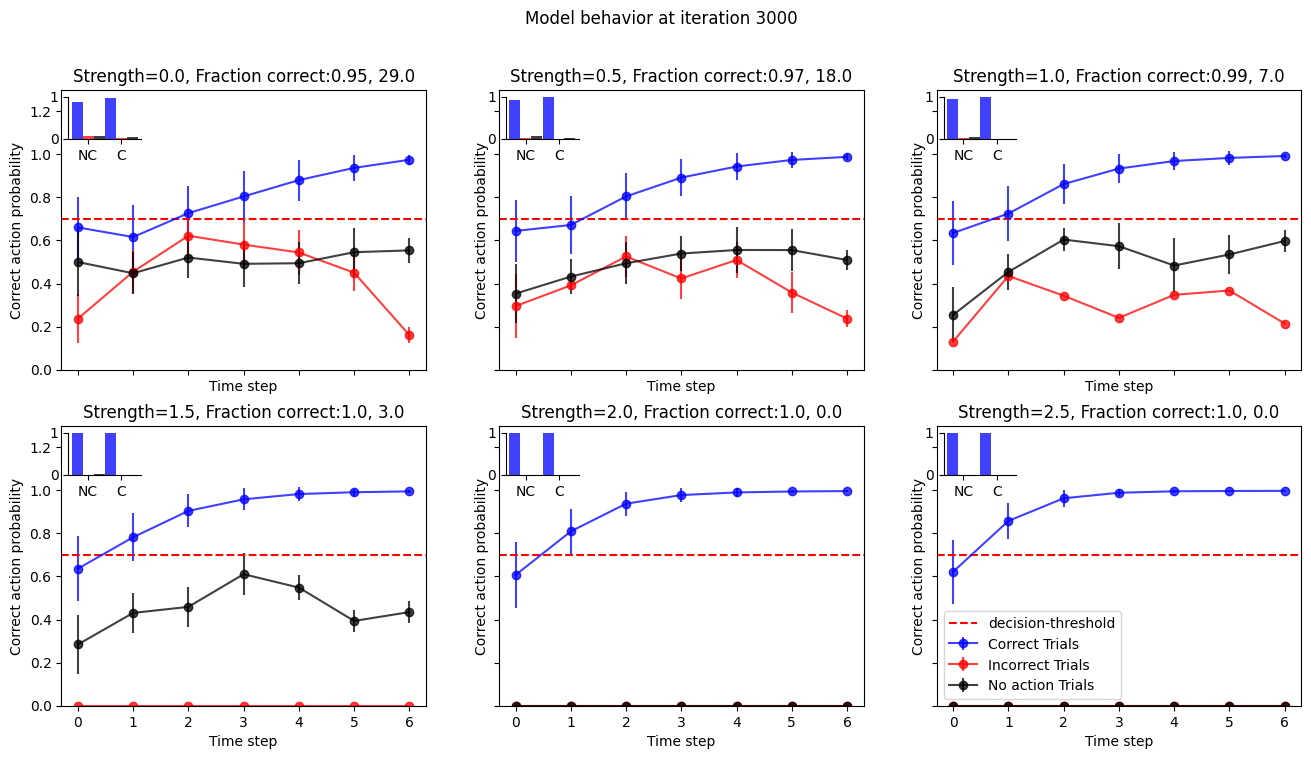

In [67]:
# plot model behavior for different session_data
# one early plot, one late plot

for itx in ["1000", "2000", "3000"]:
    iteration = itx
    session_data = load_session(
        f"../../ann-rnn-modified/data/adamalltheway/rnn_ann_model_results_10units_{iteration}.pkl"
    )

    rnn_utility.plot_probability_buildup_per_strength(session_data, iteration, 0.7)

In [68]:
# now for mutual information plots

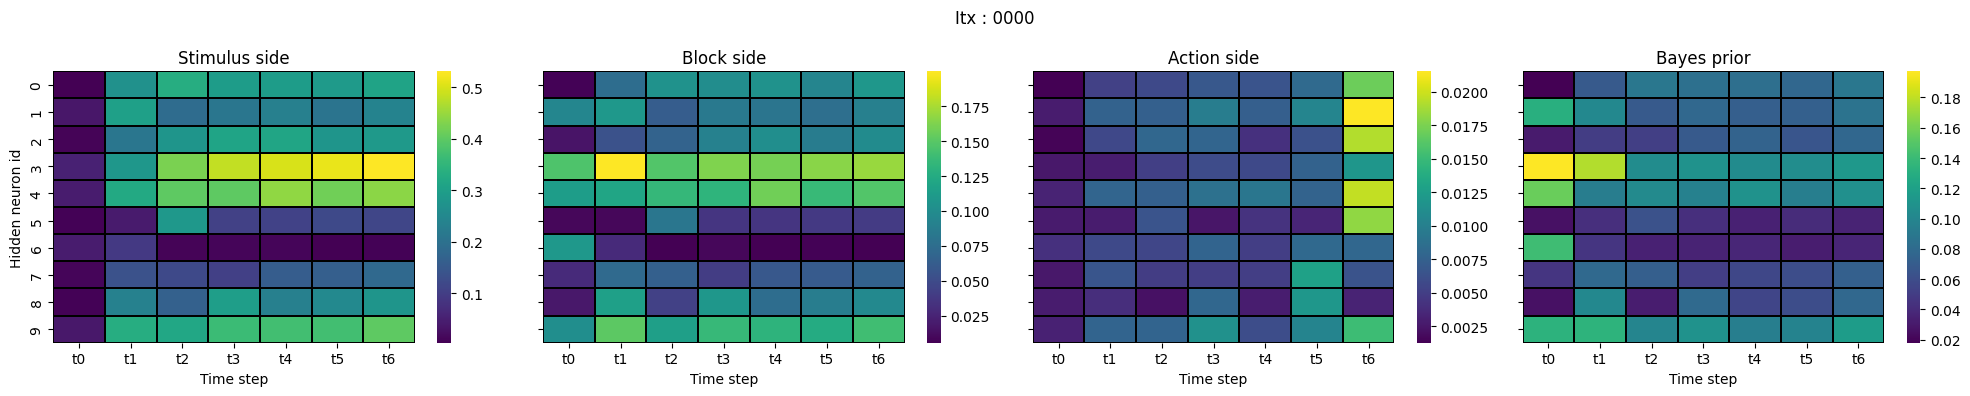

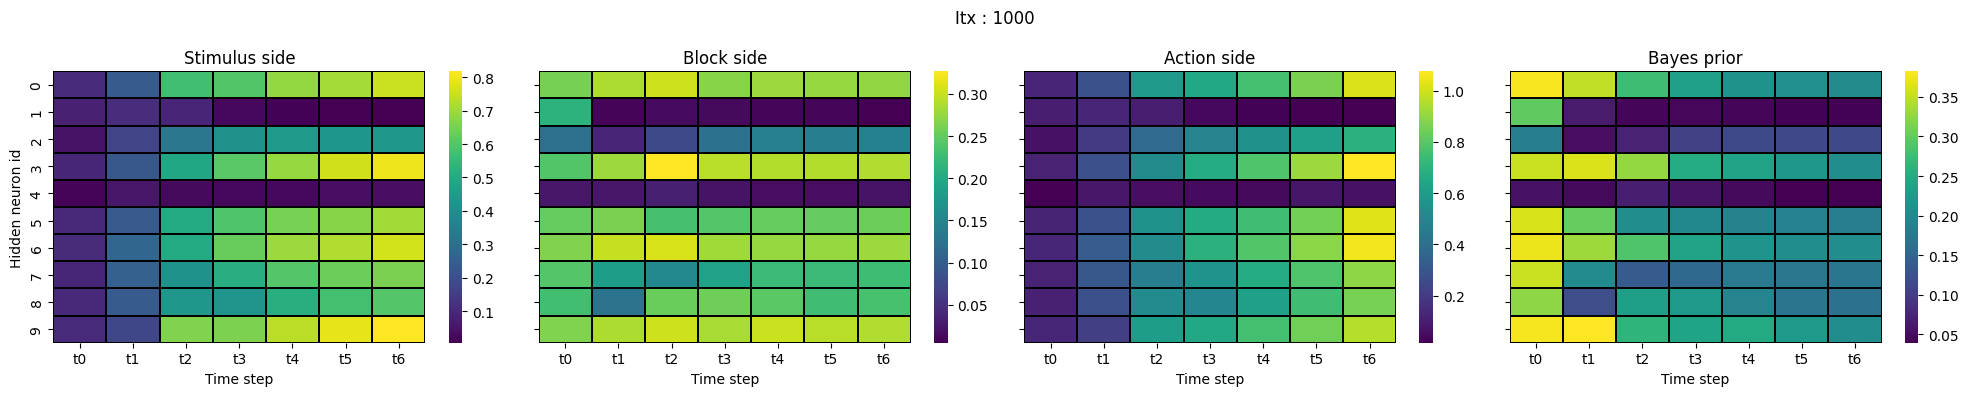

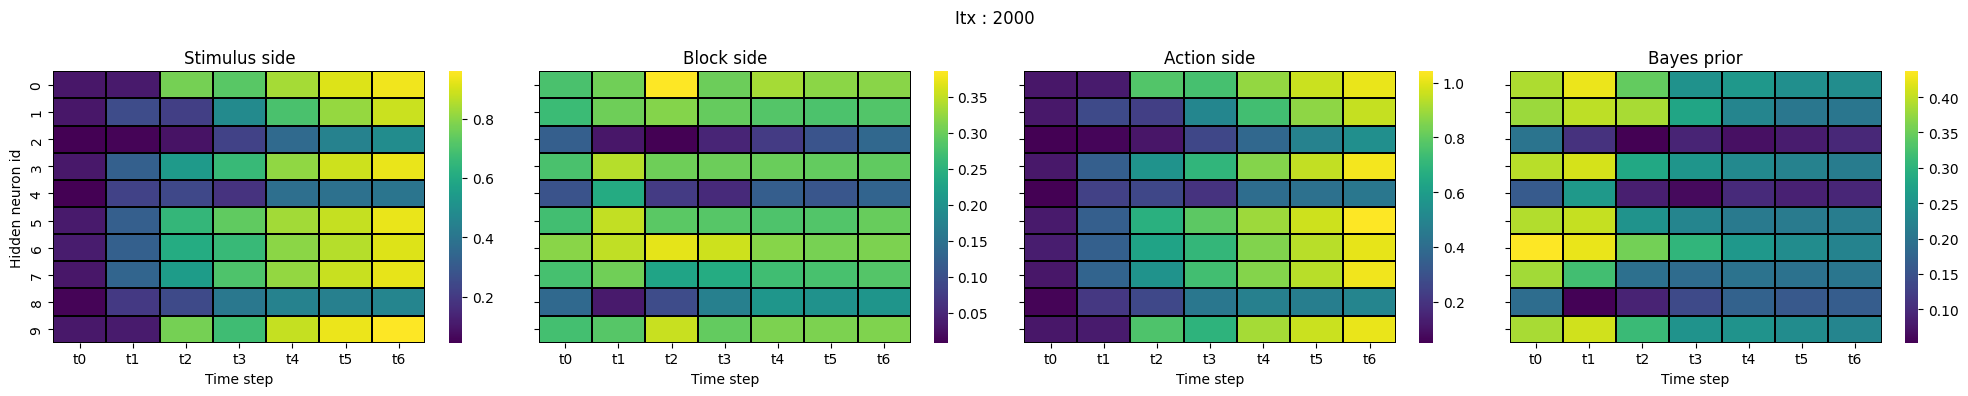

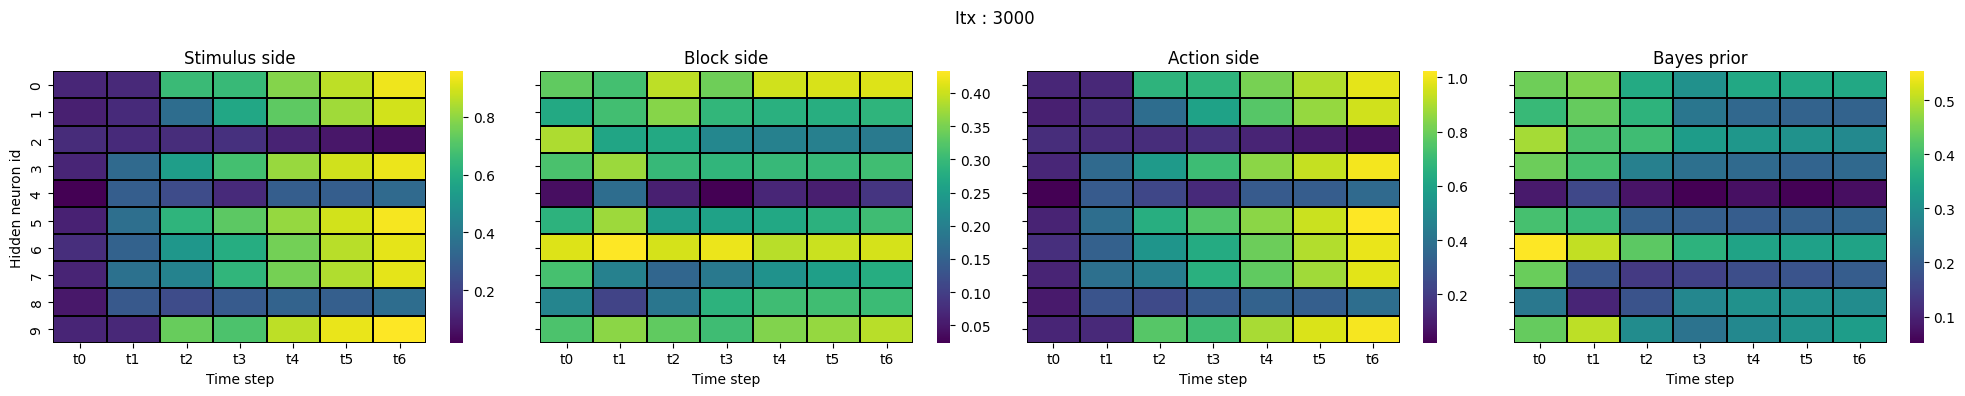

In [77]:
for itx in ["0000", "1000", "2000", "3000"]:
    iteration = itx
    session_data = load_session(
        f"../../ann-rnn-modified/data/adamalltheway/rnn_ann_model_results_10units_{iteration}.pkl"
    )

    (
        trial_side_mi,
        block_side_mi,
        action_side_mi,
        left_stim_mi,
        right_stim_mi,
        bayes_prior_mi,
        correct_action_mi,
    ) = rnn_utility.compute_mutual_information(session_data)

    rnn_utility.plot_mutual_info_heatmaps(
        trial_side_mi, block_side_mi, action_side_mi, bayes_prior_mi, correct_action_mi, iteration
    )

In [46]:
### information decomposition plots
importlib.reload(rnn_utility)

<module 'ibl_info.rnn_utility_functions' from '/Users/dkundu/Documents/phd/ibl-partial-info-decomp/ibl_info/rnn_utility_functions.py'>

In [45]:
iteration = 3000
session_data = load_session(
    f"../../ann-rnn-modified/data/adamalltheway/rnn_ann_model_results_10units_{iteration}.pkl"
)

In [47]:
trial_side_pid, block_side_pid, action_side_pid, bayes_prior_pid = (
    rnn_utility.information_decomposition_all(session_data)
)

Running for different tx: 100%|██████████| 2/2 [00:00<00:00, 2754.88it/s]
2025-01-30 16:50:17.707 | INFO     | ibl_info.config:<module>:8 - PROJ_ROOT path is: /Users/dkundu/Documents/phd/ibl-partial-info-decomp
2025-01-30 16:50:17.898 | INFO     | ibl_info.config:<module>:8 - PROJ_ROOT path is: /Users/dkundu/Documents/phd/ibl-partial-info-decomp


In [121]:
with open("./{iteration}.pkl", "rb") as f:
    pid_data = pkl.load(f)

In [135]:
trial_side_pid, block_side_pid, action_side_pid, bayes_prior_pid = (
    pid_data["trial_side"],
    pid_data["block_side"],
    pid_data["action_side"],
    pid_data["bayes_prior"],
)

In [136]:
# set to zeros

trial_side_pid[trial_side_pid < 0] = 0
block_side_pid[block_side_pid < 0] = 0
action_side_pid[action_side_pid < 0] = 0
bayes_prior_pid[bayes_prior_pid < 0] = 0

In [137]:
trial_side_pid_mean = np.mean(trial_side_pid, axis=1)
block_side_pid_mean = np.mean(block_side_pid, axis=1)
action_side_pid_mean = np.mean(action_side_pid, axis=1)
bayes_prior_pid_mean = np.mean(bayes_prior_pid, axis=1)

trial_side_pid_std = np.std(trial_side_pid, axis=1)
block_side_pid_std = np.std(block_side_pid, axis=1)
action_side_pid_std = np.std(action_side_pid, axis=1)
bayes_prior_pid_std = np.std(bayes_prior_pid, axis=1)

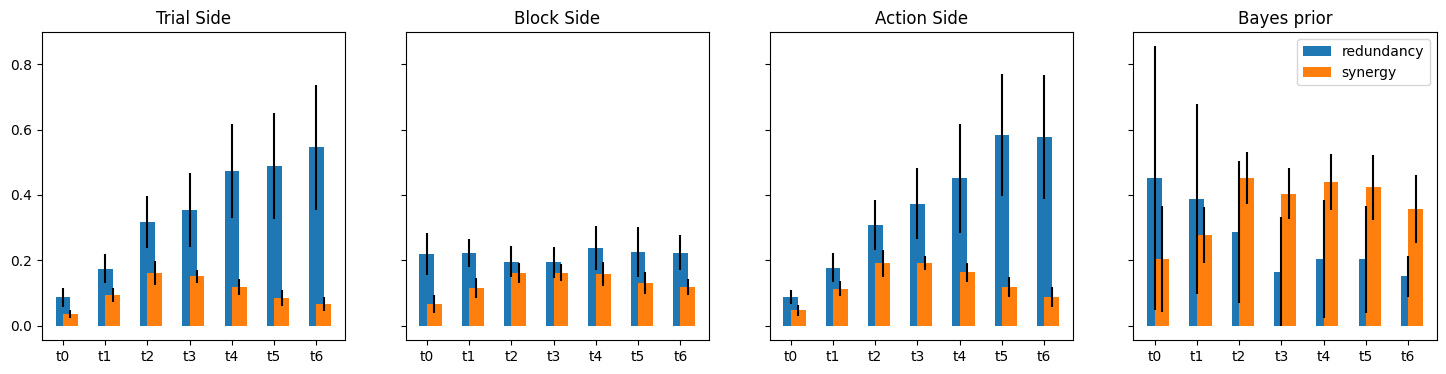

In [138]:
fig, ax = plt.subplots(ncols=4, figsize=(18, 4), sharey=True)

bar_width = 0.35

ax[0].bar(
    np.arange(7 - bar_width / 2),
    trial_side_pid_mean[:, 2],
    yerr=trial_side_pid_std[:, 2] / 2,
    label="redundancy",
    width=bar_width,
)
ax[0].bar(
    np.arange(7) + bar_width / 2,
    trial_side_pid_mean[:, 3],
    yerr=trial_side_pid_std[:, 3] / 2,
    label="synergy",
    width=bar_width,
)
ax[0].set_xticks(np.arange(7), ["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
ax[0].set_title("Trial Side")


ax[1].bar(
    np.arange(7 - bar_width / 2),
    block_side_pid_mean[:, 2],
    yerr=block_side_pid_std[:, 2] / 2,
    label="redundancy",
    width=bar_width,
)
ax[1].bar(
    np.arange(7) + bar_width / 2,
    block_side_pid_mean[:, 3],
    yerr=block_side_pid_std[:, 3] / 2,
    label="synergy",
    width=bar_width,
)
ax[1].set_xticks(np.arange(7), ["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
ax[1].set_title("Block Side")


ax[2].bar(
    np.arange(7 - bar_width / 2),
    action_side_pid_mean[:, 2],
    yerr=action_side_pid_std[:, 2] / 2,
    label="redundancy",
    width=bar_width,
)
ax[2].bar(
    np.arange(7) + bar_width / 2,
    action_side_pid_mean[:, 3],
    yerr=action_side_pid_std[:, 3] / 2,
    label="synergy",
    width=bar_width,
)
ax[2].set_xticks(np.arange(7), ["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
ax[2].set_title("Action Side")


ax[3].bar(
    np.arange(7 - bar_width / 2),
    bayes_prior_pid_mean[:, 2],
    yerr=bayes_prior_pid_std[:, 2] / 2,
    label="redundancy",
    width=bar_width,
)
ax[3].bar(
    np.arange(7) + bar_width / 2,
    bayes_prior_pid_mean[:, 3],
    yerr=bayes_prior_pid_std[:, 3] / 2,
    label="synergy",
    width=bar_width,
)
ax[3].set_xticks(np.arange(7), ["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
ax[3].set_title("Bayes prior")
ax[3].legend()